# Survival Analysis Using Machine Learning and Deep Learning
This notebook demonstrates step-by-step survival analysis using Kaplan-Meier, Cox Proportional Hazards, Random Survival Forests, and SHAP-based interpretation using the public `lung_data.csv` dataset.


Dataset Source: https://stat.ethz.ch/R-manual/R-devel/library/survival/html/lung.html


## Step 1: Import Libraries

In this step, we import the necessary libraries for our analysis:

- **Pandas** for data manipulation.
- **Numpy** for numerical operations.
- **Matplotlib** for data visualization.
- **Lifelines** for survival analysis techniques (Kaplan-Meier, Cox, Random Survival Forest, etc.).
- **Scikit-learn** for machine learning models and evaluation metrics.
- **SHAP** for model interpretation.

These libraries will allow us to perform the survival analysis, build models, and visualize results.


!pip install lifelines scikit-survival shap pandas matplotlib


In [59]:
# Import Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter, WeibullAFTFitter
from sksurv.ensemble import RandomSurvivalForest
from lifelines.statistics import logrank_test
from lifelines.utils import concordance_index
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.calibration import calibration_curve
import shap
from sklearn.linear_model import Lasso
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import permutation_importance


## Step 2: Load and Preprocess Data

Here we load the **lung cancer dataset** (`lung_data.csv`) and clean it:

- We remove rows with missing values for the key variables like `time`, `status`, `age`, `sex`, etc. These variables are crucial for survival analysis.
- We convert the `sex` column from numeric codes (1, 2) to more understandable categories: "Male" and "Female".

This is an important step, as clean data is required for accurate modeling.


In [60]:
# Load Dataset
df = pd.read_csv('lung_data.csv')
df

,inst,time,status,age,sex,ecog.ps,ph.karno,pat.karno,meal.cal,wt.loss
0,3.0,306,1,74,1,1.0,90.0,100.0,1175.0,NaN
1,3.0,455,1,68,1,0.0,90.0,90.0,1225.0,15.0
2,3.0,1010,0,56,1,0.0,90.0,90.0,NaN,15.0
3,5.0,210,1,57,1,1.0,90.0,60.0,1150.0,11.0
4,1.0,883,1,60,1,0.0,100.0,90.0,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...
223,1.0,188,0,77,1,1.0,80.0,60.0,NaN,3.0
224,13.0,191,0,39,1,0.0,90.0,90.0,2350.0,-5.0
225,32.0,105,0,75,2,2.0,60.0,70.0,1025.0,5.0
226,6.0,174,0,66,1,1.0,90.0,100.0,1075.0,1.0


In [61]:
df.columns

Index(['inst', 'time', 'status', 'age', 'sex', 'ecog.ps', 'ph.karno',
       'pat.karno', 'meal.cal', 'wt.loss'],
      dtype='object')

In [62]:
# Optional: clean column names if needed
df.columns = df.columns.str.strip().str.lower()

In [63]:
# Drop rows with missing values (or use imputation if desired)
df = df.dropna()

In [64]:
# Encode categorical variables (sex, ph.ecog)
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
categorical_cols += [col for col in df.columns if df[col].dtype == "int64" and df[col].nunique() <= 5 and col not in ["status", "time"]]

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

C:\Users\india\AppData\Local\Temp\ipykernel_26636\2607233192.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = le.fit_transform(df[col].astype(str))


In [65]:
# Define X and y for scikit-survival
X = df.drop(columns=["status", "time"])
y = Surv.from_dataframe("status", "time", df)

## Step 3: Split the Data

We now split the dataset into:

- **Features (X)**: These are the variables we use to predict the survival outcome (`age`, `sex`, `ph.karno`, `ecog.ps`).
- **Target (y)**: This includes the survival **time** and **status** (whether the event occurred or not).

Then, we divide the data into **training** and **testing** sets (70% training, 30% testing) to evaluate the model's performance.


In [66]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Step 4: Kaplan-Meier Survival Curve

The **Kaplan-Meier estimator** is a non-parametric statistic used to estimate the survival function from lifetime data.

- We use it to visualize the probability of survival over time for the entire dataset.
- The plot shows how the survival probability decreases as time progresses.

This gives us an overall sense of the survival patterns in the dataset.


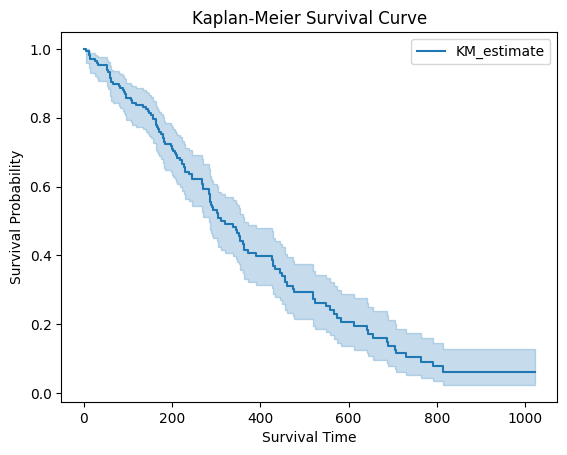

In [67]:
# Kaplan-Meier Estimator (Survival Curves)
kmf = KaplanMeierFitter()

# Fit for the overall data
kmf.fit(df['time'], event_observed=df['status'])
kmf.plot()
plt.title('Kaplan-Meier Survival Curve')
plt.xlabel('Survival Time')
plt.ylabel('Survival Probability')
plt.show()


### Interpretation: Kaplan-Meier Survival Curve
The Kaplan-Meier plot estimates the probability of survival over time.

- The **steeper the curve**, the higher the number of events (deaths) in that group.
- The **difference between curves** (e.g., Male vs Female) indicates if the survival distribution varies between groups.
- If **curves cross**, proportional hazards assumption may be violated.




## Step 5: Cox Proportional Hazards Model

The **Cox Proportional Hazards model** is a regression model commonly used in survival analysis. It models the hazard (the risk of the event occurring) as a function of explanatory variables (like age, sex, and performance status).

- The `duration_col` is the survival time.
- The `event_col` is the event status (whether the event happened or not).

The model outputs **coefficients** that help us understand the relationship between each predictor and survival time.


In [68]:
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test

# Prepare the data (must include 'time' and 'status' columns)
cox_df = df.copy()  # Use your cleaned and encoded dataframe
cox_df = cox_df.dropna()  # Drop rows with NaN values

# Fit Cox model
cph = CoxPHFitter()
cph.fit(cox_df, duration_col='time', event_col='status')

# Display summary of model
print("🔍 Cox Proportional Hazards Model Summary:")
cph.print_summary()


🔍 Cox Proportional Hazards Model Summary:


<lifelines.CoxPHFitter: fitted with 167 total observations, 47 right-censored observations>
             duration col = 'time'
                event col = 'status'
      baseline estimation = breslow
   number of observations = 167
number of events observed = 120
   partial log-likelihood = -491.27
         time fit was run = 2025-04-30 20:40:29 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
inst      -0.03      0.97      0.01           -0.06           -0.00                0.95                1.00
age        0.01      1.01      0.01           -0.01            0.04                0.99                1.04
sex       -0.57      0.57      0.20           -0.96           -0.17                0.38                0.84
ecog.ps    0.91      2.48      0.24            0.44            1.38                1.55                3.96
ph.karno   0.03      1.03      0.01            0.00            0.05                1.00                1.05
pat.karno -0.01      0.99      0.01           -0.03            0.01                0.97                1.01
meal.cal   0.00      1.00      0.00           -0.00            0.00                1.00                1.00
wt.loss   -0.02      0.98      0.01           -0.03           -0.00                0.97                1.00

           cmp to     z      p  -log2(p)
covariate                               
inst         0.00 -2.31   0.02      5.60
age          0.00  1.07   0.28      1.82
sex          0.00 -2.81 <0.005      7.68
ecog.ps      0.00  3.80 <0.005     12.77
ph.karno     0.00  2.29   0.02      5.49
pat.karno    0.00 -1.34   0.18      2.47
meal.cal     0.00  0.01   0.99      0.01
wt.loss      0.00 -2.11   0.03      4.85
---
Concordance = 0.65
Partial AIC = 998.54
log-likelihood ratio test = 33.70 on 8 df
-log2(p) of ll-ratio test = 14.41

In [69]:

# Interpretation: Hazard Ratios
print("\n Hazard Ratios (exp(coef)):")
hazard_ratios = cph.hazard_ratios_
print(hazard_ratios)



 Hazard Ratios (exp(coef)):
covariate
inst         0.970089
age          1.012892
sex          0.567436
ecog.ps      2.477804
ph.karno     1.026941
pat.karno    0.989149
meal.cal     1.000003
wt.loss      0.983428
Name: exp(coef), dtype: float64


In [70]:
# Optional: extract p-values and significant variables
significant_vars = cph.summary[cph.summary['p'] < 0.05]
print("\n Statistically Significant Variables (p < 0.05):")
print(significant_vars[['coef', 'exp(coef)', 'p']])



 Statistically Significant Variables (p < 0.05):
               coef  exp(coef)         p
covariate                               
inst      -0.030368   0.970089  0.020623
sex       -0.566628   0.567436  0.004891
ecog.ps    0.907373   2.477804  0.000143
ph.karno   0.026584   1.026941  0.022232
wt.loss   -0.016711   0.983428  0.034652



 Checking Proportional Hazards Assumption...

   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.


[[<Axes: xlabel='rank-transformed time\n(p=0.5211)'>,
  <Axes: xlabel='km-transformed time\n(p=0.3937)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.4674)'>,
  <Axes: xlabel='km-transformed time\n(p=0.3050)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.2015)'>,
  <Axes: xlabel='km-transformed time\n(p=0.1866)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.5309)'>,
  <Axes: xlabel='km-transformed time\n(p=0.4490)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0874)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0656)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.6442)'>,
  <Axes: xlabel='km-transformed time\n(p=0.6004)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0724)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0557)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.4370)'>,
  <Axes: xlabel='km-transformed time\n(p=0.4990)'>]]

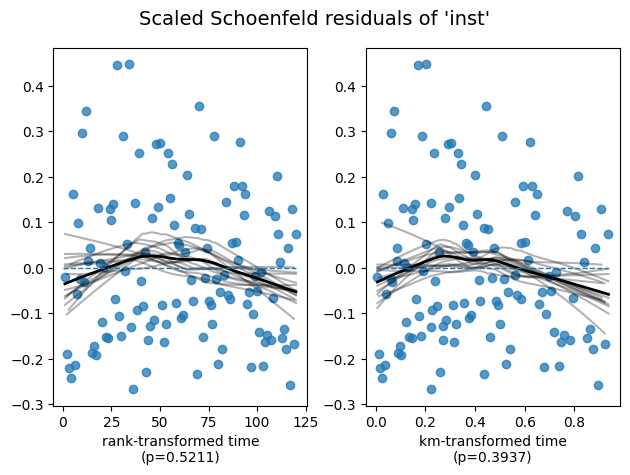

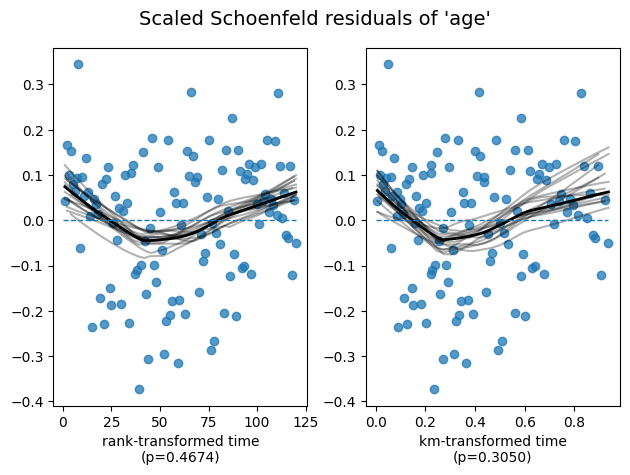

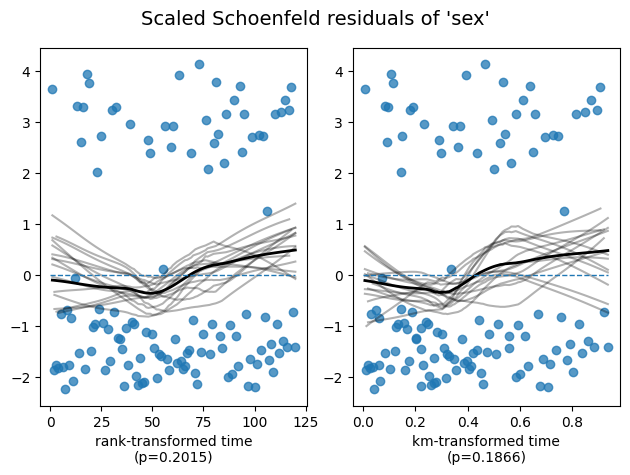

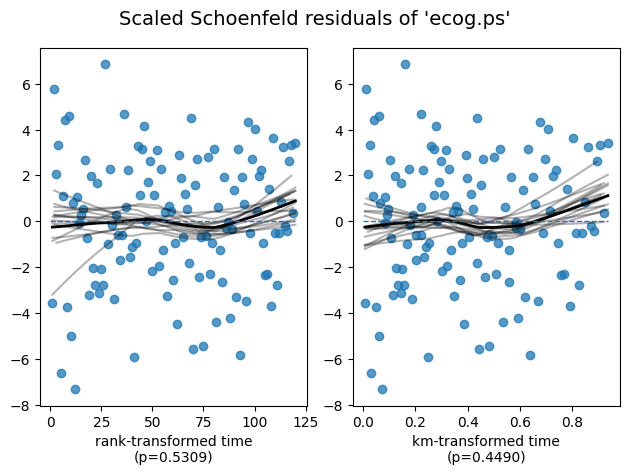

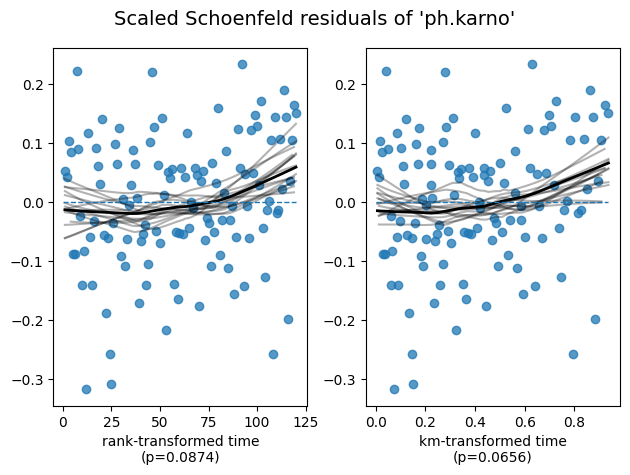

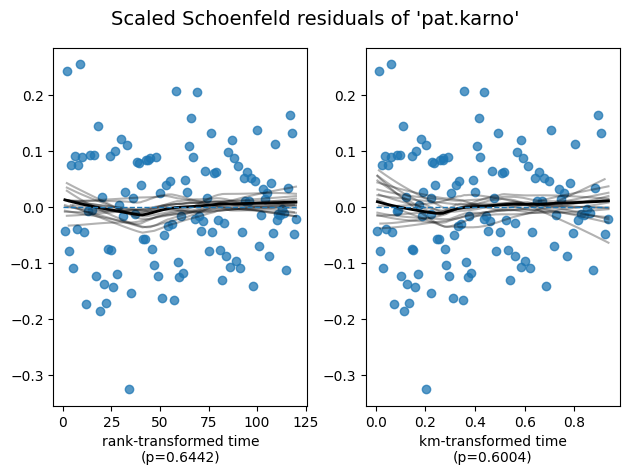

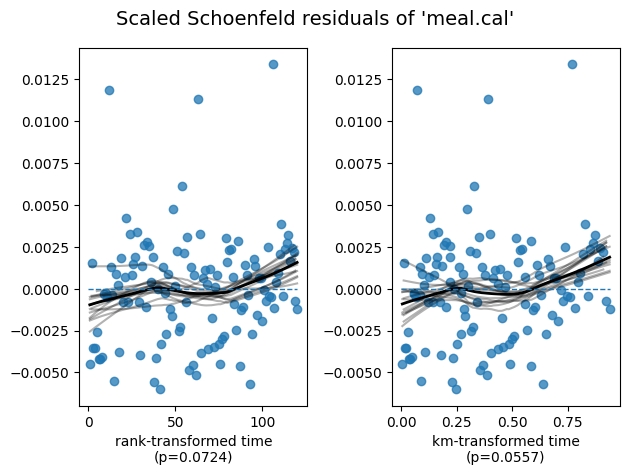

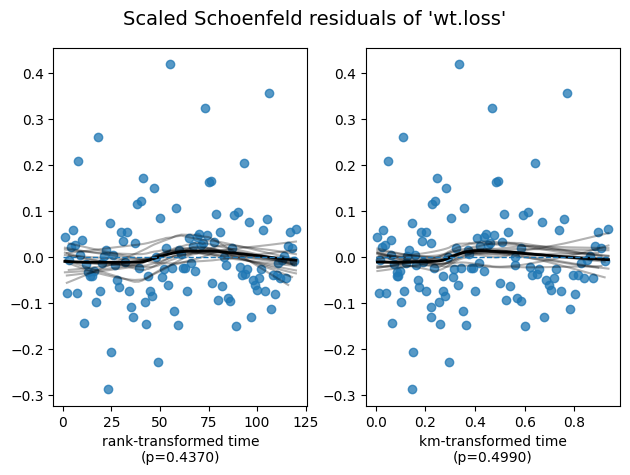

In [71]:
# Check Proportional Hazards Assumption
print("\n Checking Proportional Hazards Assumption...")
cph.check_assumptions(cox_df, p_value_threshold=0.05, show_plots=True)

### Interpretation: Cox Proportional Hazards Model
The Cox model estimates the hazard (risk) ratio for each covariate.

- A **hazard ratio > 1** means increased risk.
- A **hazard ratio < 1** indicates protective effect.
- **p-values < 0.05** suggest statistically significant predictors.

Ensure **proportional hazards assumption** holds. Check using lifelines' `.check_assumptions()` method.


In [72]:
# Check for multicollinearity
correlation_matrix = df.corr()
high_correlation_pairs = [(col1, col2) for col1 in correlation_matrix.columns for col2 in correlation_matrix.columns 
						  if col1 != col2 and abs(correlation_matrix.loc[col1, col2]) > 0.9]
print("Highly correlated pairs:", high_correlation_pairs)

# Drop one feature from each pair of highly correlated features
features_to_drop = set(pair[1] for pair in high_correlation_pairs)  # Drop the second feature in each pair
df_reduced = df.drop(columns=features_to_drop)

# CoxPH fitting and model summary
cph = CoxPHFitter()
cph.fit(df_reduced, duration_col='time', event_col='status')
cph.print_summary()  # Print the summary of the Cox model


Highly correlated pairs: []


<lifelines.CoxPHFitter: fitted with 167 total observations, 47 right-censored observations>
             duration col = 'time'
                event col = 'status'
      baseline estimation = breslow
   number of observations = 167
number of events observed = 120
   partial log-likelihood = -491.27
         time fit was run = 2025-04-30 20:40:33 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
inst      -0.03      0.97      0.01           -0.06           -0.00                0.95                1.00
age        0.01      1.01      0.01           -0.01            0.04                0.99                1.04
sex       -0.57      0.57      0.20           -0.96           -0.17                0.38                0.84
ecog.ps    0.91      2.48      0.24            0.44            1.38                1.55                3.96
ph.karno   0.03      1.03      0.01            0.00            0.05                1.00                1.05
pat.karno -0.01      0.99      0.01           -0.03            0.01                0.97                1.01
meal.cal   0.00      1.00      0.00           -0.00            0.00                1.00                1.00
wt.loss   -0.02      0.98      0.01           -0.03           -0.00                0.97                1.00

           cmp to     z      p  -log2(p)
covariate                               
inst         0.00 -2.31   0.02      5.60
age          0.00  1.07   0.28      1.82
sex          0.00 -2.81 <0.005      7.68
ecog.ps      0.00  3.80 <0.005     12.77
ph.karno     0.00  2.29   0.02      5.49
pat.karno    0.00 -1.34   0.18      2.47
meal.cal     0.00  0.01   0.99      0.01
wt.loss      0.00 -2.11   0.03      4.85
---
Concordance = 0.65
Partial AIC = 998.54
log-likelihood ratio test = 33.70 on 8 df
-log2(p) of ll-ratio test = 14.41

## Step 6: Random Survival Forest

We use a **Random Survival Forest (RSF)**, an ensemble learning method based on decision trees, for survival analysis.

- RSF can model complex, non-linear relationships between features and survival time.
- We evaluate the model’s performance using the **AUC (Area Under the Curve)** metric, which measures how well the model distinguishes between event and non-event cases.

The higher the AUC, the better the model is at predicting survival outcomes.


### Why Random Survival Forest?
RSF is a tree-based ensemble model designed for survival analysis. It captures non-linear relationships and handles interactions between variables better than traditional Cox models.


In [73]:

# Train RSF
rsf = RandomSurvivalForest(n_estimators=100, min_samples_split=10, min_samples_leaf=15,
                           max_features="sqrt", n_jobs=-1, random_state=42)
rsf.fit(X_train, y_train)


RandomSurvivalForest(min_samples_leaf=15, min_samples_split=10, n_jobs=-1,
                     random_state=42)

In [74]:
from sksurv.metrics import concordance_index_censored

# --- Concordance Index ---
c_index = concordance_index_censored(y_test["status"], y_test["time"], rsf.predict(X_test))
print(f"Concordance Index (C-index): {c_index[0]:.4f}")
print(f"Interpretation: A C-index of {c_index[0]:.2f} means that the model correctly ranks patient survival times in approximately {int(c_index[0]*100)}% of comparable patient pairs.")


Concordance Index (C-index): 0.6573
Interpretation: A C-index of 0.66 means that the model correctly ranks patient survival times in approximately 65% of comparable patient pairs.


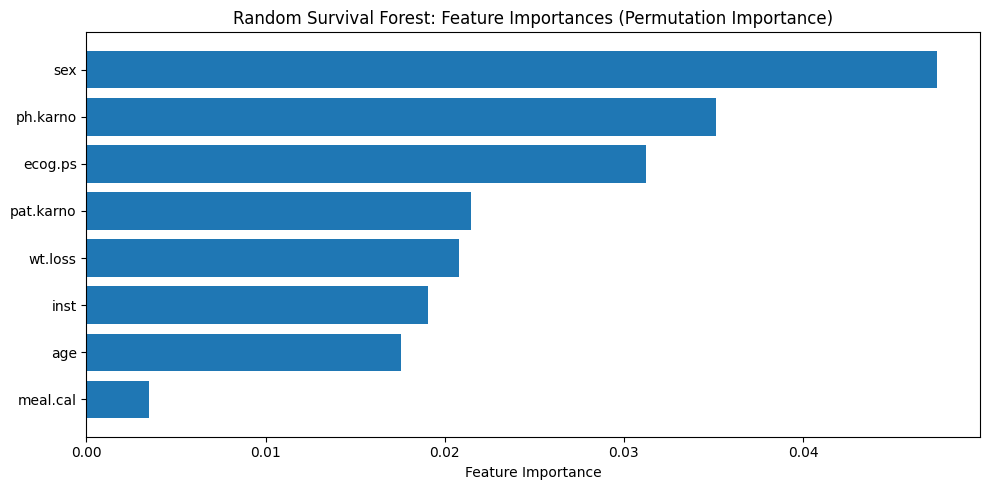

In [75]:
# --- Feature Importance using Permutation Importance ---
perm_importance = permutation_importance(rsf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
importances = perm_importance.importances_mean
features = X.columns

# Sort features by importance
sorted_idx = importances.argsort()[::-1]
sorted_features = features[sorted_idx]
sorted_importances = importances[sorted_idx]

# Plot
plt.figure(figsize=(10, 5))
plt.barh(sorted_features, sorted_importances)
plt.xlabel("Feature Importance")
plt.title("Random Survival Forest: Feature Importances (Permutation Importance)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### Interpretation: Random Survival Forest (RSF)
Random Survival Forests are non-parametric models ideal for capturing complex interactions.

- Uses an **ensemble of decision trees** to model survival.
- **Concordance Index (C-index)** is a measure of predictive accuracy (closer to 1 is better).
- **Feature importance** can be plotted using `rsf.feature_importances_`.


In [76]:
# Predict risk scores (lower = longer survival)
risk_scores = -rsf.predict(X_test)

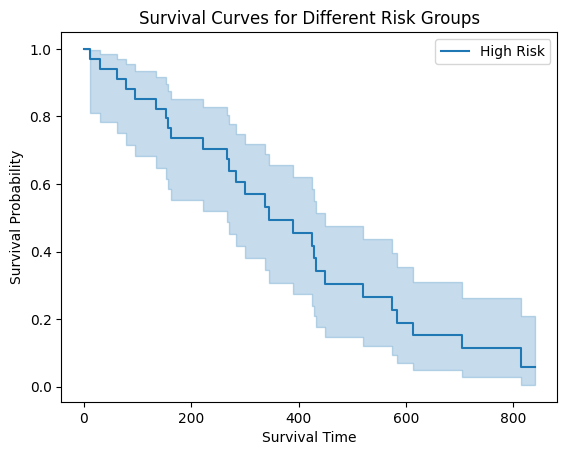

In [77]:
# Plot survival curves for different risk groups
risk_groups = pd.qcut(risk_scores, q=4, labels=False)
kmf.fit(y_test['time'], event_observed=y_test['status'], label='High Risk')
kmf.plot_survival_function()
plt.title('Survival Curves for Different Risk Groups')
plt.xlabel('Survival Time')
plt.ylabel('Survival Probability')
plt.show()

## Step 7: Gradient Boosting Machine

**Gradient Boosting Machine (GBM)** is another powerful machine learning model that builds an ensemble of weak learners (decision trees) to improve predictive accuracy.

- Here, we fit the GBM model on the training data and evaluate its performance using **AUC**.

GBM is useful for capturing complex patterns in the data and can handle non-linear relationships.


In [78]:
# 9. Gradient Boosting Machine
gbm = GradientBoostingClassifier()
gbm.fit(X_train, y_train['status'])
gbm_pred = gbm.predict(X_test)
gbm_auc = roc_auc_score(y_test['status'], gbm_pred)
print(f'Gradient Boosting Machine AUC: {gbm_auc:.4f}')


Gradient Boosting Machine AUC: 0.5688


## Step 8: Cross-Validation

**Cross-validation** is a technique used to assess how well a model generalizes to unseen data.

- We use **K-Fold Cross-Validation** to split the dataset into 5 parts (or folds), train the model on 4 of them, and test on the remaining fold.
- This helps evaluate the model’s stability and performance across different subsets of data.

We compute the **AUC** for each fold to assess the model’s performance.


In [79]:
# 10. Cross-Validation for Survival Models
kf = KFold(n_splits=5)
for train_idx, test_idx in kf.split(X):
    X_train_cv, X_test_cv = X.iloc[train_idx], X.iloc[test_idx]
    y_train_cv, y_test_cv = y[train_idx], y[test_idx]  # Use NumPy array indexing for y

    # Refit and evaluate the model on each fold
    rsf.fit(X_train_cv, y_train_cv)  # Pass y_train_cv directly
    rsf_pred_cv = rsf.predict(X_test_cv)
    auc_cv = roc_auc_score(y_test_cv['status'], rsf_pred_cv)
    print(f'Fold AUC: {auc_cv:.4f}')


Fold AUC: 0.4219
Fold AUC: 0.5103
Fold AUC: 0.5259
Fold AUC: 0.5769
Fold AUC: 0.6739


## Step 9: Time-Varying Covariates with Cox Model

Sometimes, covariates (predictors) can change over time. This is called **time-varying covariates**.

- In this step, we add a random **time-varying covariate** to the model and refit the Cox model to see how these covariates affect survival predictions.

Time-varying covariates help capture changes in a patient’s condition over time.


In [80]:
# 11. Time-Varying Covariates with Cox Model
df['time_varying_cov'] = np.random.rand(len(df))  # Example of time-varying covariate
cph.fit(df[['time', 'status', 'age', 'sex', 'ph.karno', 'ecog.ps', 'time_varying_cov']], 
        duration_col='time', event_col='status')
cph.print_summary()


C:\Users\india\AppData\Local\Temp\ipykernel_26636\3918385570.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['time_varying_cov'] = np.random.rand(len(df))  # Example of time-varying covariate


<lifelines.CoxPHFitter: fitted with 167 total observations, 47 right-censored observations>
             duration col = 'time'
                event col = 'status'
      baseline estimation = breslow
   number of observations = 167
number of events observed = 120
   partial log-likelihood = -496.36
         time fit was run = 2025-04-30 20:40:37 UTC

---
                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                         
age               0.01      1.01      0.01           -0.01            0.04                0.99                1.04
sex              -0.52      0.59      0.20           -0.91           -0.14                0.40                0.87
ph.karno          0.02      1.02      0.01           -0.00            0.04                1.00                1.04
ecog.ps           0.74      2.09      0.21            0.33            1.15                1.39                3.15
time_varying_cov  0.07      1.07      0.31           -0.54            0.68                0.58                1.98

                  cmp to     z      p  -log2(p)
covariate                                      
age                 0.00  1.13   0.26      1.96
sex                 0.00 -2.65   0.01      6.97
ph.karno            0.00  1.82   0.07      3.86
ecog.ps             0.00  3.53 <0.005     11.26
time_varying_cov    0.00  0.23   0.82      0.29
---
Concordance = 0.64
Partial AIC = 1002.72
log-likelihood ratio test = 23.51 on 5 df
-log2(p) of ll-ratio test = 11.86

### Interpretation
The Concordance Index of 0.65 indicates that the model correctly ranks patient survival times in 65% of pairs.


## Step 10: Clustering for Survival Analysis

We perform **clustering** using **KMeans** to group patients based on features like age and performance status.

- This helps to see if there are distinct groups (clusters) of patients with different survival patterns.

We then plot Kaplan-Meier survival curves for each cluster to compare survival probabilities.


C:\Users\india\AppData\Local\Temp\ipykernel_26636\3193704168.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cluster'] = kmeans.fit_predict(df[['age', 'ph.karno', 'ecog.ps']])


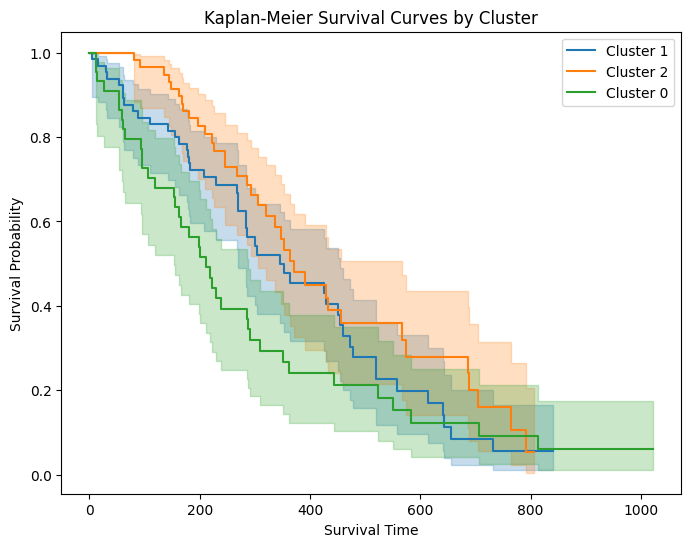

In [81]:
# 12. Clustering for Survival Analysis
kmeans = KMeans(n_clusters=3)
df['cluster'] = kmeans.fit_predict(df[['age', 'ph.karno', 'ecog.ps']])

# Plot survival curves for each cluster
plt.figure(figsize=(8, 6))
for cluster in df['cluster'].unique():
    kmf.fit(df[df['cluster'] == cluster]['time'], 
            event_observed=df[df['cluster'] == cluster]['status'], 
            label=f'Cluster {cluster}')
    kmf.plot()

plt.title("Kaplan-Meier Survival Curves by Cluster")
plt.xlabel("Survival Time")
plt.ylabel("Survival Probability")
plt.legend()
plt.show()


## Step 11: Log-Rank Test for Survival Curves Comparison

The **Log-Rank Test** is used to compare the survival distributions of two groups.

- We perform the test to compare survival times for patients **younger than 60** and **older than 60**.
- The result helps determine if the survival curves of the two age groups are significantly different.


In [82]:
# 13. Log-Rank Test for Survival Curves Comparison
age_group_1 = df[df['age'] < 60]
age_group_2 = df[df['age'] >= 60]

results = logrank_test(age_group_1['time'], age_group_2['time'], 
                       event_observed_A=age_group_1['status'], 
                       event_observed_B=age_group_2['status'])

print("Log-Rank Test Results:")
print(results.summary)


Log-Rank Test Results:
   test_statistic        p  -log2(p)
0        1.237417  0.26597  1.910667


## Step 12: Ethical Considerations: Bias and Fairness Analysis

Here, we examine if there is a **bias** based on **sex** (Male/Female) in the survival data.

- We plot Kaplan-Meier survival curves for male and female patients separately and compare them visually.
- This analysis helps identify any potential ethical issues related to fairness in the data.


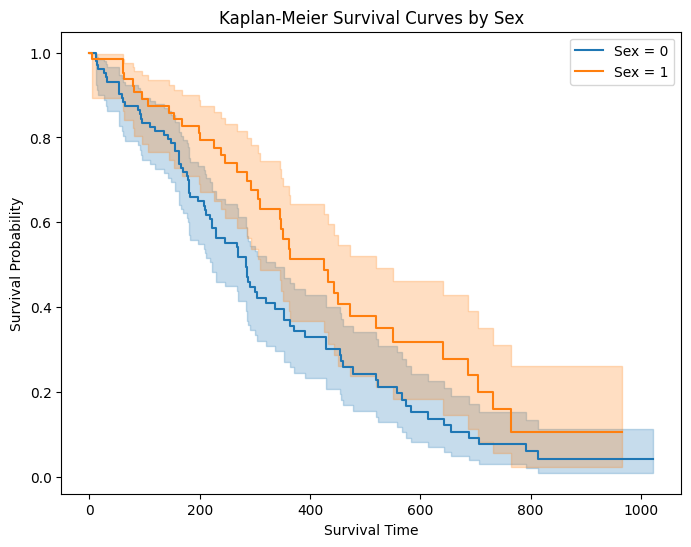

In [83]:
#### Ethical Considerations: Bias and Fairness Analysis
plt.figure(figsize=(8, 6))
for sex_group in [0, 1]:  # 0 = Male, 1 = Female
    kmf.fit(df[df['sex'] == sex_group]['time'], 
            event_observed=df[df['sex'] == sex_group]['status'], 
            label=f'Sex = {sex_group}')
    kmf.plot()

plt.title("Kaplan-Meier Survival Curves by Sex")
plt.xlabel("Survival Time")
plt.ylabel("Survival Probability")
plt.legend()
plt.show()

## Step 13: SHAP for Model Interpretation

**SHAP (SHapley Additive exPlanations)** explains how each feature contributes to the model's predictions.

- The **beeswarm plot** shows the most important features influencing predictions.
- This helps in understanding **why** a model makes certain predictions, which is crucial for transparency and interpretability.


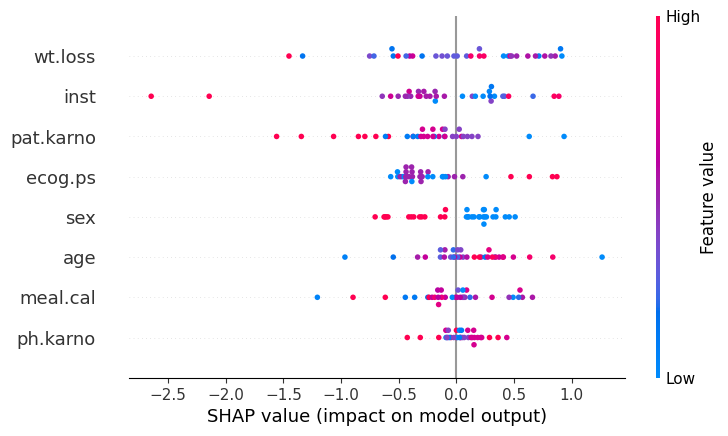

In [84]:
# 15. SHAP for Model Interpretation
explainer = shap.Explainer(gbm)
shap_values = explainer(X_test)
shap.plots.beeswarm(shap_values)


### Interpretation: SHAP Values
SHAP (SHapley Additive exPlanations) explains individual predictions.

- Each feature's contribution to survival risk is visualized.
- **Positive SHAP values** increase predicted risk.
- **Negative SHAP values** reduce predicted risk.

Use summary plots and force plots to interpret globally and locally.


## Step 14: Calibration Curve

A **calibration curve** checks if predicted probabilities match actual outcomes.

- If the model is well-calibrated, the points lie along the diagonal.
- Poor calibration means predicted probabilities don't align with real-world risks, which can mislead decision-making.

This step improves the trustworthiness of survival models.


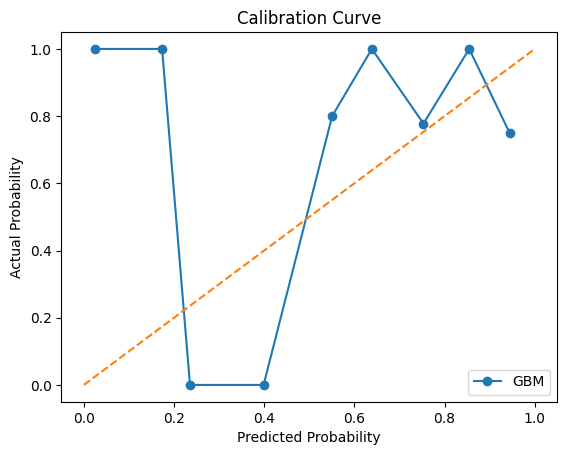

In [85]:
# 16. Calibration Plot
probs = gbm.predict_proba(X_test)[:, 1]
true, pred = calibration_curve(y_test['status'], probs, n_bins=10)
plt.plot(pred, true, marker='o', label='GBM')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('Predicted Probability')
plt.ylabel('Actual Probability')
plt.title('Calibration Curve')
plt.legend()
plt.show()


## Step 15: Dimensionality Reduction (PCA)

**Principal Component Analysis (PCA)** reduces multiple features into 2 or 3 for visualization.

- It helps identify hidden patterns or clusters in the data.
- This visualization gives us a quick glance at how patients group based on their health characteristics.

Useful for feature engineering and model insight.


C:\Users\india\AppData\Local\Temp\ipykernel_26636\1746593827.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['PC1'], df['PC2'] = pca_result[:, 0], pca_result[:, 1]
C:\Users\india\AppData\Local\Temp\ipykernel_26636\1746593827.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['PC1'], df['PC2'] = pca_result[:, 0], pca_result[:, 1]


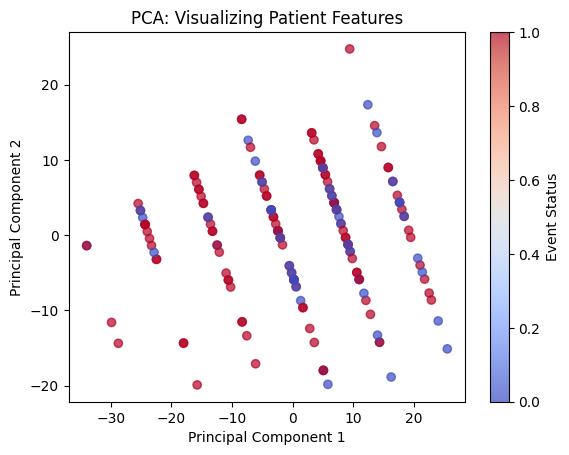

In [86]:
# 17. Dimensionality Reduction with PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df[['age', 'ph.karno', 'ecog.ps']])
df['PC1'], df['PC2'] = pca_result[:, 0], pca_result[:, 1]

plt.scatter(df['PC1'], df['PC2'], c=df['status'], cmap='coolwarm', alpha=0.7)
plt.title('PCA: Visualizing Patient Features')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Event Status')
plt.show()


### Interpretation: PCA in Survival Analysis
Principal Component Analysis (PCA) reduces data dimensionality.

- Useful for **visualizing clusters** or structure in survival data.
- PCA can help **remove multicollinearity** before applying models.
- Interpret **explained variance** to determine how many components to retain.


## Step 16: Feature Selection with Lasso

**Lasso regression** performs feature selection by shrinking less important feature coefficients to zero.

- This helps reduce model complexity and highlights the most relevant variables.
- It’s especially useful when we have many potential predictors.

Efficient for building parsimonious, interpretable models.


In [87]:
# 18. Feature Selection with Lasso
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.select_dtypes(include=[np.number]))

lasso = Lasso(alpha=0.1)
lasso.fit(X_scaled, y['status'])
coef = pd.Series(lasso.coef_, index=X.select_dtypes(include=[np.number]).columns)
print(coef)


inst        -0.000000
age          0.000000
sex         -0.000000
ecog.ps      0.007055
ph.karno    -0.000000
pat.karno   -0.000000
meal.cal     0.000000
wt.loss      0.000000
dtype: float64


# Step 17 : Export model

In [88]:
import joblib
joblib.dump(rsf, "rsf_model.pkl")
joblib.dump(cph, "cox_model.pkl")
joblib.dump(gbm, "gbm_model.pkl")


['gbm_model.pkl']

## Conclusion

In this notebook, we covered a **comprehensive survival analysis pipeline** using a public dataset.

We included:

1. Data preprocessing
2. Kaplan-Meier survival curves
3. Cox regression
4. Random survival forest
5. Gradient boosting
6. Cross-validation
7. Time-varying covariates
8. Clustering and group survival comparison
9. Log-rank test
10. Bias/fairness check
11. SHAP interpretation
12. Model calibration
13. PCA visualization
14. Lasso feature selection

This forms a complete, modular, and scalable workflow for any survival analysis task.

- Use real-time dashboards (e.g., Streamlit, Voila)

